# 05 · Modelos: Random Forest (baseline) + XGBoost (principal)

**Proyecto:** LINE — Auditor Médico Digital · Health & Life IPS SAS

Entrena y evalúa los dos modelos tabulares con un diseño comparable al
notebook CNN del Capstone (split 70/30 estratificado, `SEED=42`).

| Entrada | Salida |
|---|---|
| `data/processed/dataset_maestro.csv` | `outputs/models/*.joblib` (4 pipelines) |
| `outputs/reports/columnas_modelado.json` | `outputs/reports/metrics.json` |
| | `outputs/tables/importancias_*.csv` |
| | `outputs/figures/roc_*.png`, `importancias_*.png` |

**Dos escenarios de features** para una comparación honesta con el CNN:
- **A_produccion** — todas las features disponibles en producción, incluidos
  los flags de cruce.
- **B_features_cnn** — exactamente las features que usó el CNN, para aislar el
  efecto del algoritmo.

**Política de umbral:** en auditoría médica preferimos falsos positivos
(revisión manual extra) a dejar pasar inconsistencias → se reporta también el
umbral que maximiza F1 sujeto a **recall ≥ 85 %**.

## 0 · Configuración (celda autocontenida)

In [1]:
from pathlib import Path
import json
import os
import time

import matplotlib

try:
    get_ipython  # noqa: B018
except NameError:
    matplotlib.use("Agg")

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import (accuracy_score, confusion_matrix, f1_score,
                             precision_recall_curve, precision_score,
                             recall_score, roc_auc_score, roc_curve)
from sklearn.model_selection import StratifiedKFold, cross_validate, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from xgboost import XGBClassifier

SEED = 42

try:
    ROOT = Path(__file__).resolve().parents[1]
except NameError:
    ROOT = Path.cwd()
    if ROOT.name in ("notebooks", "src"):
        ROOT = ROOT.parent

DATA_PROC = ROOT / "data" / "processed"
OUT_MOD = ROOT / "outputs" / "models"
OUT_REP = ROOT / "outputs" / "reports"
OUT_TAB = ROOT / "outputs" / "tables"
OUT_FIG = ROOT / "outputs" / "figures"
for _d in (OUT_MOD, OUT_REP, OUT_TAB, OUT_FIG):
    _d.mkdir(parents=True, exist_ok=True)

try:
    display  # noqa: B018
except NameError:
    display = print


def reintentar(fn, intentos=6, espera=0.5):
    for _i in range(intentos):
        try:
            return fn()
        except OSError:
            if _i == intentos - 1:
                raise
            time.sleep(espera * (2 ** _i))


def to_csv_seguro(df, path, **kw):
    path = Path(path)
    tmp = path.with_suffix(path.suffix + ".tmp")
    reintentar(lambda: df.to_csv(tmp, **kw))
    reintentar(lambda: os.replace(tmp, path))


def write_text_seguro(path, texto, encoding="utf-8"):
    path = Path(path)
    tmp = path.with_suffix(path.suffix + ".tmp")
    reintentar(lambda: tmp.write_text(texto, encoding=encoding))
    reintentar(lambda: os.replace(tmp, path))


ENTRADAS = [DATA_PROC / "dataset_maestro.csv", OUT_REP / "columnas_modelado.json"]
_faltan = [str(p_) for p_ in ENTRADAS if not p_.exists()]
assert not _faltan, (
    "FALTAN INSUMOS:\n  - " + "\n  - ".join(_faltan)
    + "\n→ Ejecuta primero el notebook 02_dataset_maestro.ipynb."
)

m = pd.read_csv(DATA_PROC / "dataset_maestro.csv")
cols = json.loads((OUT_REP / "columnas_modelado.json").read_text(encoding="utf-8"))
FEATURES_NUM = cols["features_numericas"]
FEATURES_CAT = cols["features_categoricas"]

CNN_NUM = ["edad", "cantidad_realizada", "cantidad_facturada",
           "valor_unitario", "valor_total", "mes_atencion"]
CNN_CAT = ["sexo", "eps_atencion", "tipo_afiliacion", "ciudad", "tipo_documento",
           "tipo_atencion", "sede", "tipo_item", "soporte_clinico",
           "diagnostico_principal_cie10", "medico_tratante", "profesional_responsable"]

y = m["target"].values
print(f"Dataset: {m.shape[0]:,} filas | positivos: {y.sum()} ({y.mean()*100:.1f}%)")

Dataset: 3,126 filas | positivos: 649 (20.8%)


## 1 · Pipeline de preprocesamiento y funciones de evaluación
El preprocesamiento vive DENTRO del pipeline sklearn (imputación + one-hot),
así el `.joblib` exportado recibe el DataFrame crudo sin transformaciones
manuales — clave para inferencia sin errores de desalineación.

In [2]:
def construir_pipeline(modelo, num, cat):
    prep = ColumnTransformer([
        ("num", SimpleImputer(strategy="constant", fill_value=-1), num),
        ("cat", Pipeline([
            ("imp", SimpleImputer(strategy="constant", fill_value="SIN_DATO")),
            ("ohe", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
        ]), cat),
    ])
    return Pipeline([("prep", prep), ("clf", modelo)])


def umbral_recall(y_true, y_prob, recall_min=0.85):
    """Umbral que maximiza F1 sujeto a recall >= recall_min."""
    prec, rec, thr = precision_recall_curve(y_true, y_prob)
    f1s = 2 * prec * rec / (prec + rec + 1e-12)
    validos = rec[:-1] >= recall_min
    idx = (np.where(validos)[0][np.argmax(f1s[:-1][validos])]
           if validos.any() else int(np.argmax(f1s[:-1])))
    return float(thr[idx])


def evaluar(nombre, pipe, Xtr, Xte, ytr, yte, escenario, resultados):
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
    cv_res = cross_validate(pipe, Xtr, ytr, cv=cv,
                            scoring=["roc_auc", "f1", "recall", "precision"])
    pipe.fit(Xtr, ytr)
    prob = pipe.predict_proba(Xte)[:, 1]

    metricas = {}
    for th_name, th in [("th_0.50", 0.5), ("th_recall85", umbral_recall(yte, prob))]:
        pred = (prob >= th).astype(int)
        tn, fp, fn, tp = confusion_matrix(yte, pred).ravel()
        metricas[th_name] = {
            "threshold": round(float(th), 4),
            "accuracy": round(accuracy_score(yte, pred), 4),
            "precision": round(precision_score(yte, pred, zero_division=0), 4),
            "recall": round(recall_score(yte, pred), 4),
            "f1": round(f1_score(yte, pred), 4),
            "matriz": {"tn": int(tn), "fp": int(fp), "fn": int(fn), "tp": int(tp)},
        }
    resultados["escenarios"].setdefault(escenario, {})[nombre] = {
        "cv_5fold_train": {k.replace("test_", ""): f"{v.mean():.4f} +/- {v.std():.4f}"
                           for k, v in cv_res.items() if k.startswith("test_")},
        "test_auc_roc": round(float(roc_auc_score(yte, prob)), 4),
        "test": metricas,
    }
    return pipe, prob


def graficar_importancias(pipe, nombre, escenario, top=20):
    prep = pipe.named_steps["prep"]
    nombres = prep.get_feature_names_out()
    imp = pipe.named_steps["clf"].feature_importances_
    df = (pd.DataFrame({"feature": nombres, "importancia": imp})
          .sort_values("importancia", ascending=False))
    to_csv_seguro(df, OUT_TAB / f"importancias_{nombre}_{escenario}.csv", index=False)
    topdf = df.head(top).iloc[::-1]
    fig, ax = plt.subplots(figsize=(9, 6))
    ax.barh(topdf["feature"].str.replace("num__", "").str.replace("cat__", ""),
            topdf["importancia"], color="#1565c0")
    ax.set_title(f"Top {top} importancias - {nombre.upper()} ({escenario})")
    fig.tight_layout()
    reintentar(lambda: fig.savefig(OUT_FIG / f"importancias_{nombre}_{escenario}.png",
                                   dpi=130, bbox_inches="tight"))
    plt.show()
    plt.close(fig)
    return df

## 2 · Entrenamiento y evaluación en los dos escenarios
Random Forest usa `class_weight='balanced'`; XGBoost usa `scale_pos_weight`
igual al ratio negativos/positivos del train. La validación cruzada 5-fold
sobre el train da la banda de varianza de las métricas.

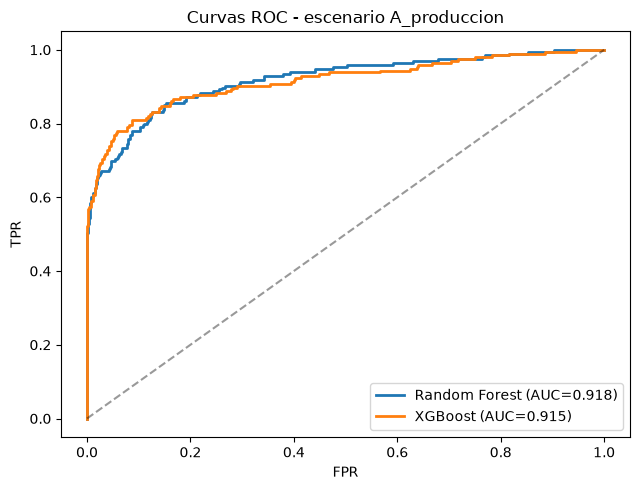

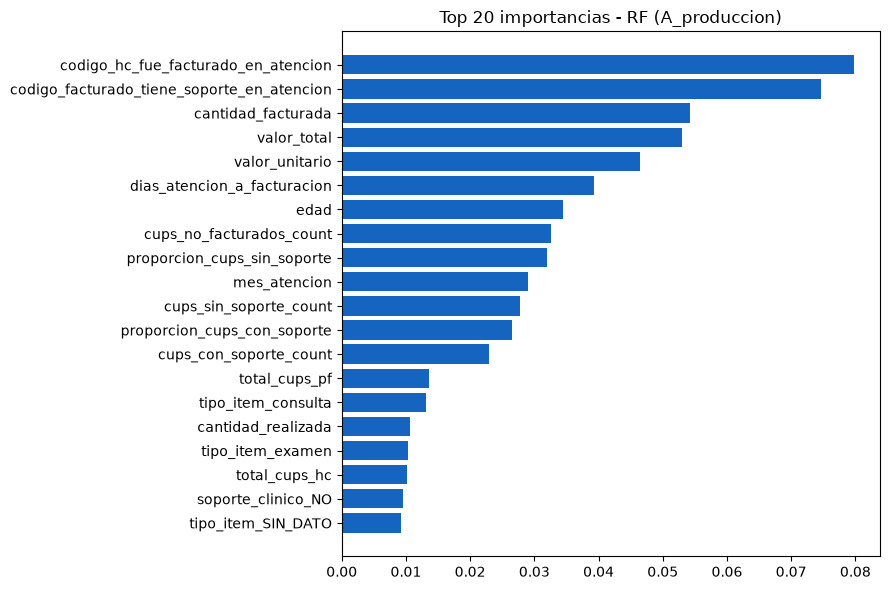

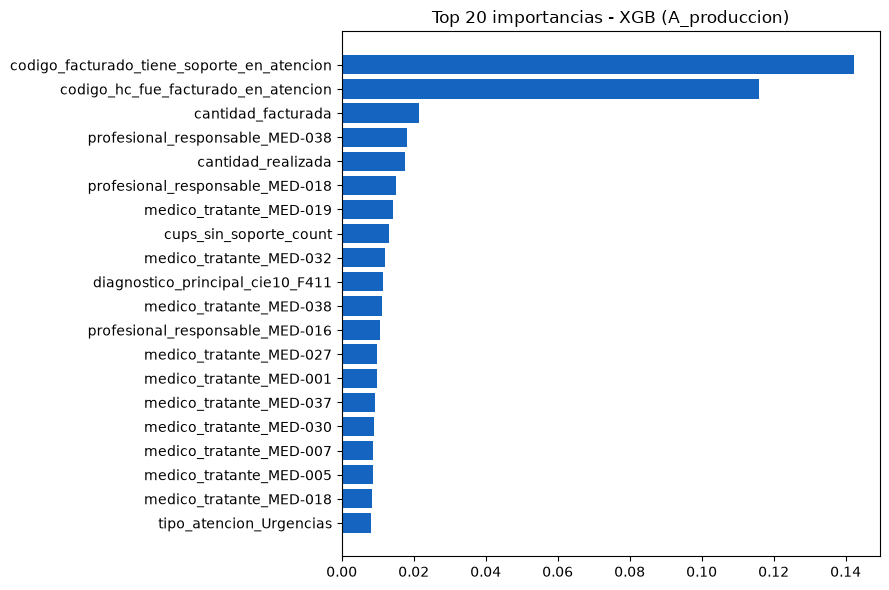

[A_produccion] modelos guardados en outputs/models/


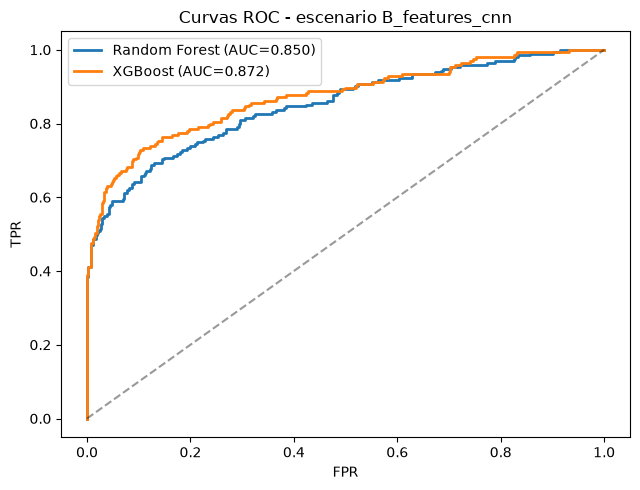

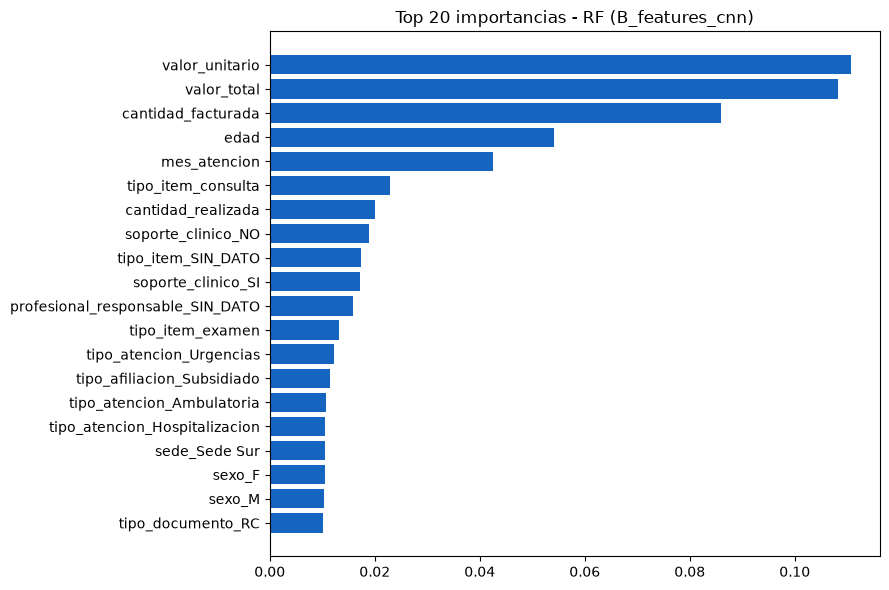

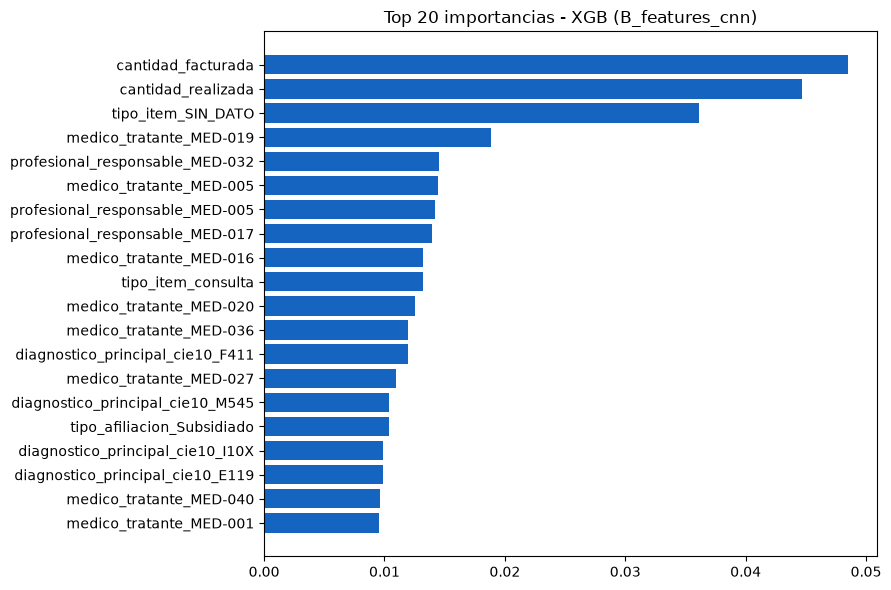

[B_features_cnn] modelos guardados en outputs/models/


In [3]:
resultados = {"seed": SEED, "split": "70/30 estratificado", "escenarios": {}}

for escenario, (num, cat) in {
    "A_produccion": (FEATURES_NUM, FEATURES_CAT),
    "B_features_cnn": (CNN_NUM, CNN_CAT),
}.items():
    X = m[num + cat]
    Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.3, random_state=SEED, stratify=y)
    spw = float((ytr == 0).sum() / (ytr == 1).sum())

    rf = construir_pipeline(
        RandomForestClassifier(n_estimators=400, class_weight="balanced",
                               min_samples_leaf=2, n_jobs=-1, random_state=SEED), num, cat)
    xgb = construir_pipeline(
        XGBClassifier(n_estimators=500, learning_rate=0.08, max_depth=6,
                      subsample=0.9, colsample_bytree=0.9, scale_pos_weight=spw,
                      eval_metric="auc", random_state=SEED, n_jobs=-1), num, cat)

    rf, prob_rf = evaluar("random_forest", rf, Xtr, Xte, ytr, yte, escenario, resultados)
    xgb, prob_xgb = evaluar("xgboost", xgb, Xtr, Xte, ytr, yte, escenario, resultados)

    # Curvas ROC comparativas del escenario
    fig, ax = plt.subplots(figsize=(6.5, 5))
    for nom, prob in [("Random Forest", prob_rf), ("XGBoost", prob_xgb)]:
        fpr, tpr, _ = roc_curve(yte, prob)
        ax.plot(fpr, tpr, lw=2, label=f"{nom} (AUC={roc_auc_score(yte, prob):.3f})")
    ax.plot([0, 1], [0, 1], "k--", alpha=0.4)
    ax.set_title(f"Curvas ROC - escenario {escenario}")
    ax.set_xlabel("FPR")
    ax.set_ylabel("TPR")
    ax.legend()
    fig.tight_layout()
    reintentar(lambda: fig.savefig(OUT_FIG / f"roc_{escenario}.png", dpi=130, bbox_inches="tight"))
    plt.show()
    plt.close(fig)

    _ = graficar_importancias(rf, "rf", escenario)
    _ = graficar_importancias(xgb, "xgb", escenario)

    reintentar(lambda: joblib.dump(rf, OUT_MOD / f"random_forest_{escenario}.joblib"))
    reintentar(lambda: joblib.dump(xgb, OUT_MOD / f"xgboost_{escenario}.joblib"))
    print(f"[{escenario}] modelos guardados en outputs/models/")

## 3 · Referencia CNN y exportación de métricas
Las métricas del CNN provienen de los outputs guardados del notebook original
del equipo — **no re-ejecutables en esta copia** (el binario del modelo no
está; ver `docs/AUDIT_PROYECTO.md` §3.1). Se citan como referencia, no como
resultado reproducido.

In [4]:
resultados["cnn_referencia_reportada"] = {
    "fuente": "04_NOTEBOOKS/02_modelo_cnn_transfer_learning.ipynb (outputs guardados)",
    "nota": "No re-ejecutable en esta copia: SavedModel incompleto y sin .h5",
    "test_auc_roc": 0.7487,
    "th_0.50": {"accuracy": 0.8539, "precision": 0.9531, "recall": 0.3385, "f1": 0.4710},
    "th_0.388": {"accuracy": 0.70, "precision": 0.3848, "recall": 0.7538, "f1": 0.5095},
}
write_text_seguro(OUT_REP / "metrics.json", json.dumps(resultados, ensure_ascii=False, indent=2))

# Tabla resumen legible
filas = []
for esc, modelos in resultados["escenarios"].items():
    for nombre, r in modelos.items():
        t5, t85 = r["test"]["th_0.50"], r["test"]["th_recall85"]
        filas.append({"escenario": esc, "modelo": nombre, "AUC": r["test_auc_roc"],
                      "F1@0.5": t5["f1"], "recall@0.5": t5["recall"],
                      "recall@th_ajustado": t85["recall"], "precision@th_ajustado": t85["precision"]})
filas.append({"escenario": "B (reportado)", "modelo": "CNN MobileNetV2", "AUC": 0.7487,
              "F1@0.5": 0.4710, "recall@0.5": 0.3385,
              "recall@th_ajustado": 0.7538, "precision@th_ajustado": 0.3848})
display(pd.DataFrame(filas))
print(f"\nMétricas completas: {OUT_REP / 'metrics.json'}")

,escenario,modelo,AUC,F1@0.5,recall@0.5,recall@th_ajustado,precision@th_ajustado
0,A_produccion,random_forest,0.9185,0.7346,0.6103,0.8513,0.6014
1,A_produccion,xgboost,0.9152,0.7738,0.7282,0.8615,0.5833
2,B_features_cnn,random_forest,0.8500,0.6138,0.4564,0.8513,0.3458
3,B_features_cnn,xgboost,0.8724,0.7009,0.6308,0.8564,0.4154
4,B (reportado),CNN MobileNetV2,0.7487,0.4710,0.3385,0.7538,0.3848



Métricas completas: c:\Users\MIGI\Desktop\LINE\outputs\reports\metrics.json


## ✅ Verificación de cierre
Deben existir: 4 `.joblib` en `outputs/models/`, `metrics.json` en
`outputs/reports/`, 4 CSV de importancias en `outputs/tables/` y 6 PNG nuevos
en `outputs/figures/`. Resultados esperados (seed fija): XGBoost AUC ≈ 0.901
en escenario A y ≈ 0.872 en escenario B, vs 0.749 del CNN reportado.